In [1]:
# This notebook runs our framework on Knapsack problems!

In [2]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import random

from qiskit import transpile
from qiskit.circuit import Parameter,ParameterExpression
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeManilaV2,FakeNairobiV2,FakeMelbourneV2,FakeGuadalupeV2
import stim
from qiskit_optimization.applications import Knapsack
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit.circuit.library import QAOAAnsatz


import sys
sys.path.append("../")
from clapton.clapton import claptonize
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, generate_qiskit_param_map
from testing_scripts.graphs_utils import generate_random_complete_graph,generate_k_regular_graph

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [3]:
prob = Knapsack(values=[1, 2,3,4], weights=[1, 2,3,4], max_weight=4)
qp = prob.to_quadratic_program()
print(qp.prettyprint())

# intermediate QUBO form of the optimization problem
conv = QuadraticProgramToQubo()
qubo = conv.convert(qp)

# qubit Hamiltonian and offset
op, offset = qubo.to_ising()
print(f"num qubits: {op.num_qubits}, offset: {offset}\n")
print(op)

cost_hamiltonian = op
paulis,coeffs = cost_hamiltonian.paulis.to_labels(),cost_hamiltonian.coeffs.real
reversed_paulis = [p[::-1] for p in paulis]

Problem name: Knapsack

Maximize
  x_0 + 2*x_1 + 3*x_2 + 4*x_3

Subject to
  Linear constraints (1)
    x_0 + 2*x_1 + 3*x_2 + 4*x_3 <= 4  'c0'

  Binary variables (4)
    x_0 x_1 x_2 x_3

num qubits: 7, offset: 193.0

SparsePauliOp(['IIIIIIZ', 'IIIIIZI', 'IIIIZII', 'IIIZIII', 'IIZIIII', 'IZIIIII', 'ZIIIIII', 'IIIIIZZ', 'IIIIZIZ', 'IIIZIIZ', 'IIZIIIZ', 'IZIIIIZ', 'ZIIIIIZ', 'IIIIZZI', 'IIIZIZI', 'IIZIIZI', 'IZIIIZI', 'ZIIIIZI', 'IIIZZII', 'IIZIZII', 'IZIIZII', 'ZIIIZII', 'IIZZIII', 'IZIZIII', 'ZIIZIII', 'IZZIIII', 'ZIZIIII', 'ZZIIIII'],
              coeffs=[ -32.5+0.j,  -65. +0.j,  -97.5+0.j, -130. +0.j,  -33. +0.j,  -66. +0.j,
  -33. +0.j,   11. +0.j,   16.5+0.j,   22. +0.j,    5.5+0.j,   11. +0.j,
    5.5+0.j,   33. +0.j,   44. +0.j,   11. +0.j,   22. +0.j,   11. +0.j,
   66. +0.j,   16.5+0.j,   33. +0.j,   16.5+0.j,   22. +0.j,   44. +0.j,
   22. +0.j,   11. +0.j,    5.5+0.j,   11. +0.j])


In [4]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=1)
dec_circ = circuit

In [5]:
# Transform qiskit circ. to stim.
modified_circ = modify_circuit(dec_circ)
pcirc = transform_to_allowed_gates(modified_circ)

In [6]:
def parameter_renaming(dec_circ):
    dag = circuit_to_dag(dec_circ)
    gamma_counter, beta_counter = 0, 0
    angle_multipliers = {}
    for node in dag.op_nodes():
        if node.op.params and isinstance(node.op.params[0], ParameterExpression):
            param_name = list(node.op.params[0].parameters)[0].name 
            if "β" in param_name:

                multiplier = float(str(node.op.params[0]).split("*")[0])

                beta = Parameter(f'{multiplier}*beta_{beta_counter}')
                new_params = [beta if (isinstance(p, ParameterExpression)) else p for p in node.op.params]
                new_op = node.op.copy()
                new_op.params = new_params  # Create a modified version of the operation
                dag.substitute_node(node, new_op)  # Replace the node in the DAG
                beta_counter += 1

                angle_multipliers[beta.name] = multiplier
            

            elif "γ" in param_name:

                multiplier = float(str(node.op.params[0]).split("*")[0])
                
                gamma = Parameter(f'{multiplier}*gamma_{gamma_counter}')
                new_params = [gamma if (isinstance(p, ParameterExpression)) else p for p in node.op.params]
                new_op = node.op.copy()
                new_op.params = new_params  # Create a modified version of the operation
                dag.substitute_node(node, new_op)  # Replace the node in the DAG
                gamma_counter += 1

                angle_multipliers[gamma.name] = multiplier

    # Convert DAG back to a circuit
    new_qc = dag_to_circuit(dag)
    return new_qc, circuit_to_dag(new_qc) , angle_multipliers

# Usage
pcirc, dag , angle_multipliers= parameter_renaming(pcirc)

In [7]:
# # Transform qiskit circ. to stim.
# modified_circ = modify_circuit(dec_circ) #circuit
# pcirc = transform_to_allowed_gates(modified_circ)

stim_circ = qiskit_to_stim(pcirc)
stim_circ.stim_circuit().diagram()

q0: -H-I---@---@---@---@---------@---@---------------@---@---------------------@---@---------------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------------------------------------------------------------------------------------------------------
           |   |   |   |         |   |               |   |                     |   |                           |   |
q1: ---H-I-X-I-X---|---|-@---@---|---|-@---@---------|---|-@---@---------------|---|-@---@---------------------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------------------------------------------------------------------------------
                   |   | |   |   |   | |   |         |   | |   |               |   | |   |                     |   |                   |   |
q2: -----------H-I-X-I-X-X-I-X---|---|-|---|-@---@---|---|-|---|-@---@---------|---|-|---|-@---@---------------|---|-------------------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------------------------------------------------------
                                 |   | |   | |   |   |   | |   | |   |         |   | |   | |   |               |   |                   |   |                   |   |
q3: -------------------------H-I-X-I-X-X-I-X-X-I-X---|---|-|---|-|---|-@---@---|---|-|---|-|---|-@---@---------|---|-------------------|---|-------------------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------------------------------
                                                     |   | |   | |   | |   |   |   | |   | |   | |   |         |   |                   |   |                   |   |                   |   |
q4: ---------------------------------------------H-I-X-I-X-X-I-X-X-I-X-X-I-X---|---|-|---|-|---|-|---|-@---@---|---|-------------------|---|-------------------|---|-------------------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------
                                                                               |   | |   | |   | |   | |   |   |   |                   |   |                   |   |                   |   |                   |   |
q5: -----------------------------------------------------------------------H-I-X-I-X-X-I-X-X-I-X-X-I-X-X-I-X---|---|-------------------|---|-------------------|---|-------------------|---|-------------------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------
                                                                                                               |   |                   |   |                   |   |                   |   |                   |   |                   |   |
q6: -------------------------------------------------------------------------------------------------------H-I-X-I-X-------------------X-I-X-------------------X-I-X-------------------X-I-X-------------------X-I-X-------------------X-I-X-------------------S-SQRT_X-I-SQRT_X-S-

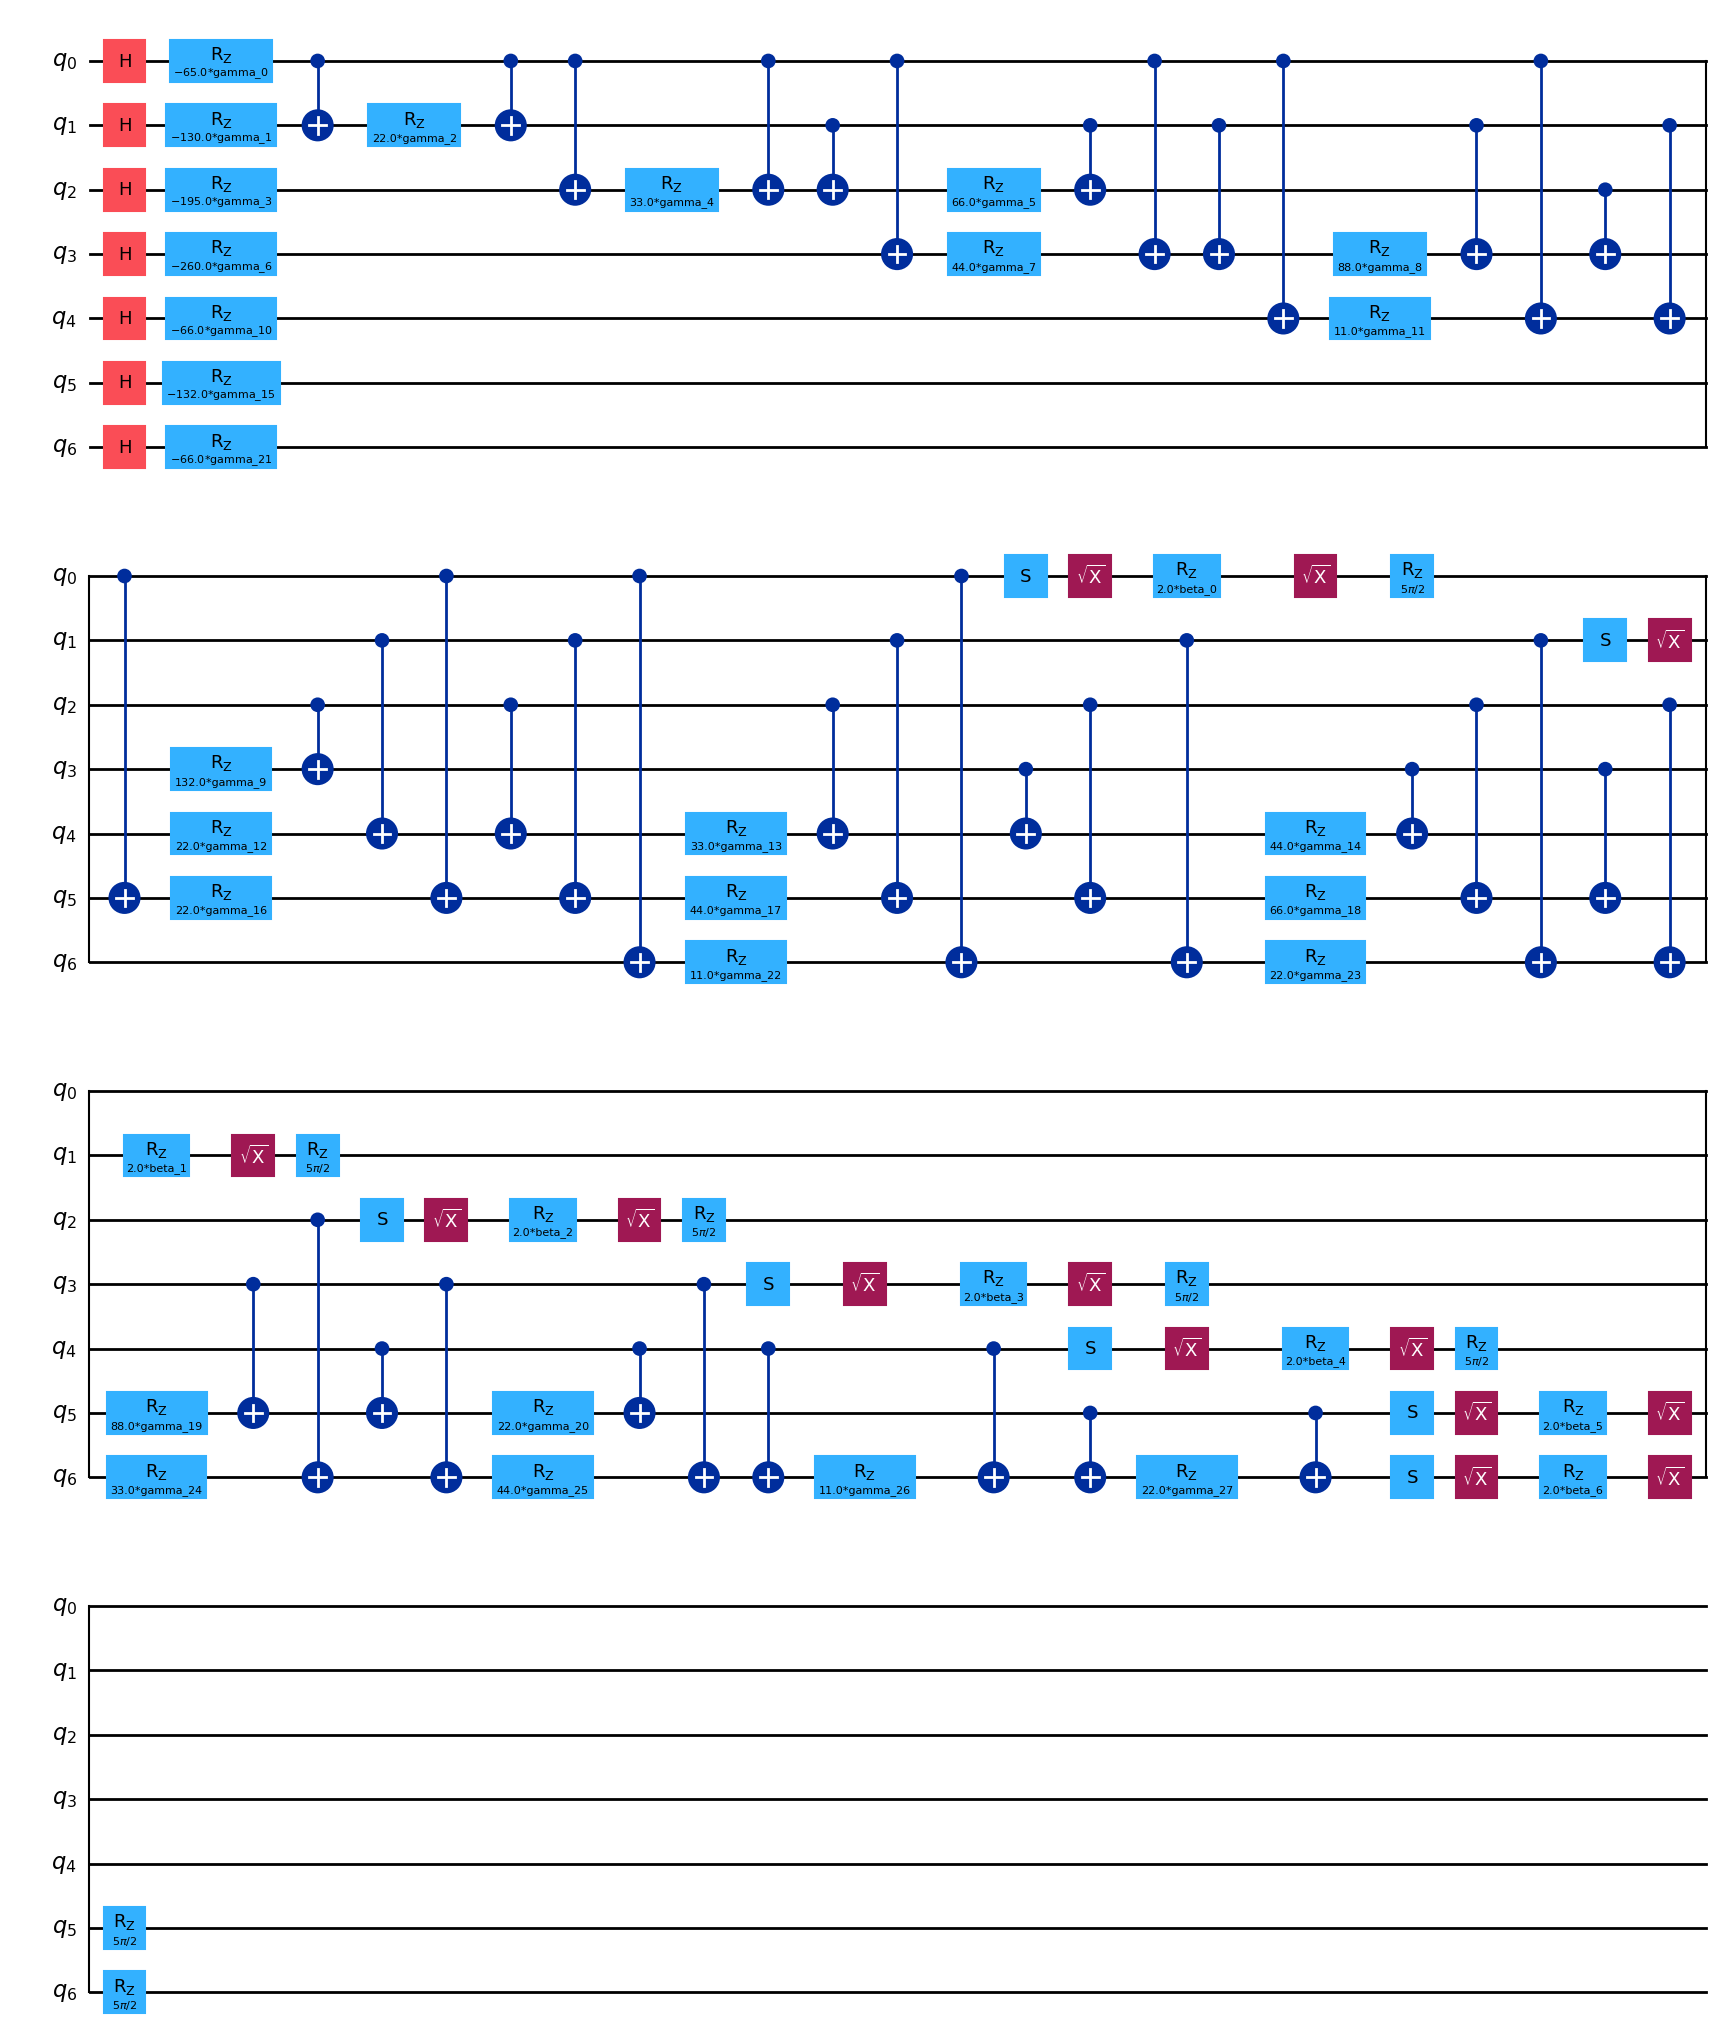

In [8]:
pcirc.draw('mpl')

In [9]:
param_map = generate_qiskit_param_map(pcirc)

In [10]:
stim_circ.define_parameter_map(param_map)

In [11]:
## Random Params

# ks_best = []
# random.seed(311) #7
# for i in range(pcirc.num_parameters):
#     ks_best.append(random.randint(0, 3))
    
# we can perform CAFQA by using the main optimization function "claptonize"
ks_best, _, energy_best = claptonize(
    reversed_paulis,    #to respect stim ordering for hamiltonian
    coeffs,
    stim_circ,
    n_proc=4,           # total number of processes in parallel
    n_starts=4,         # number of random genetic algorithm starts in parallel
    n_rounds=1,         # number of budget rounds, if None it will terminate itself
    callback=print,     # callback for internal parameter (#iteration, energies, ks) processing
    budget=10       # budget per genetic algorithm instance
)


stim_circ.assign(ks_best)

energy_best

STARTING ROUND 0


started GA at id 1 with 1 procs

started GA at id 2 with 1 procs


/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")


GA parameters used for this experiment:
  num_generations=10
  num_parents_mating=20
  population_size=100
  num_genes=35
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5

started GA at id 3 with 1 procs

started GA at id None with 1 procs

GA parameters used for this experiment:
  num_generations=10
  num_parents_mating=20
  population_size=100
  num_genes=35
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5


/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")


GA parameters used for this experiment:
  num_generations=10
  num_parents_mating=20
  population_size=100
  num_genes=35
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5

/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")


/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")


GA parameters used for this experiment:
  num_generations=10
  num_parents_mating=20
  population_size=100
  num_genes=35
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5
[0, array([-195. ,  -97.5,  -97.5,    0. ]), array([1, 3, 3, 2, 0, 2, 1, 3, 1, 2, 2, 3, 0, 1, 0, 2, 1, 2, 3, 1, 2, 2,
       1, 2, 0, 2, 0, 1, 2, 0, 3, 0, 0, 1, 0], dtype=object)]
[0, array([-195. ,  -97.5,  -97.5,    0. ]), array([1, 3, 3, 2, 0, 2, 1, 3, 1, 2, 2, 3, 0, 1, 0, 2, 1, 2, 3, 1, 2, 2,
       1, 2, 0, 2, 0, 1, 2, 0, 3, 0, 0, 1, 0], dtype=object)]
[0, array([-195. ,  -97.5,  -97.5,    0. ]), array([1, 3, 3, 2, 0, 2, 1, 3, 1, 2, 2, 3, 0, 1, 0, 2, 1, 2, 3, 1, 2, 2,
       1, 2, 0, 2, 0, 1, 2, 0, 3, 0, 0, 1, 0], dtype=object)]
[0, array([-195. ,  -97.5,  -97.5,    0. ]), array([1, 3, 3, 2, 0, 2, 1, 3, 1, 2, 2, 3, 0, 1, 0, 2, 1, 2, 3, 1, 2, 2,
       1, 2, 0, 2, 0, 1, 2, 0, 

np.float64(-129.5)

In [12]:
def stim_exp_val(stim_qc,paulis,coeffs):
    sim = stim.TableauSimulator()
    sim.do_circuit(stim_qc)
    pauli_expect = [sim.peek_observable_expectation(stim.PauliString(p)) for p in paulis] #need paulis
    loss = np.inner(coeffs, pauli_expect)
    return loss

stim_energy = stim_exp_val(stim_circ.stim_circuit(), reversed_paulis, coeffs)
print(stim_energy)


-129.5


In [13]:
def cafqa_params_energy(circuit, hamiltonian, parameters):
    estimator = Estimator(mode=AerSimulator(method='statevector'))
    isa_hamiltonian = hamiltonian.apply_layout(circuit.layout)

    pub = (circuit, isa_hamiltonian, parameters)
    job = estimator.run([pub])

    results = job.result()[0]
    return results.data.evs

In [14]:
pcirc.parameters

ParameterView([Parameter(-130.0*gamma_1), Parameter(-132.0*gamma_15), Parameter(-195.0*gamma_3), Parameter(-260.0*gamma_6), Parameter(-65.0*gamma_0), Parameter(-66.0*gamma_10), Parameter(-66.0*gamma_21), Parameter(11.0*gamma_11), Parameter(11.0*gamma_22), Parameter(11.0*gamma_26), Parameter(132.0*gamma_9), Parameter(2.0*beta_0), Parameter(2.0*beta_1), Parameter(2.0*beta_2), Parameter(2.0*beta_3), Parameter(2.0*beta_4), Parameter(2.0*beta_5), Parameter(2.0*beta_6), Parameter(22.0*gamma_12), Parameter(22.0*gamma_16), Parameter(22.0*gamma_2), Parameter(22.0*gamma_20), Parameter(22.0*gamma_23), Parameter(22.0*gamma_27), Parameter(33.0*gamma_13), Parameter(33.0*gamma_24), Parameter(33.0*gamma_4), Parameter(44.0*gamma_14), Parameter(44.0*gamma_17), Parameter(44.0*gamma_25), Parameter(44.0*gamma_7), Parameter(66.0*gamma_18), Parameter(66.0*gamma_5), Parameter(88.0*gamma_19), Parameter(88.0*gamma_8)])

In [15]:
angle_multipliers

{'-65.0*gamma_0': -65.0,
 '-130.0*gamma_1': -130.0,
 '22.0*gamma_2': 22.0,
 '-195.0*gamma_3': -195.0,
 '33.0*gamma_4': 33.0,
 '66.0*gamma_5': 66.0,
 '-260.0*gamma_6': -260.0,
 '44.0*gamma_7': 44.0,
 '88.0*gamma_8': 88.0,
 '132.0*gamma_9': 132.0,
 '-66.0*gamma_10': -66.0,
 '11.0*gamma_11': 11.0,
 '22.0*gamma_12': 22.0,
 '33.0*gamma_13': 33.0,
 '44.0*gamma_14': 44.0,
 '-132.0*gamma_15': -132.0,
 '22.0*gamma_16': 22.0,
 '44.0*gamma_17': 44.0,
 '66.0*gamma_18': 66.0,
 '88.0*gamma_19': 88.0,
 '22.0*gamma_20': 22.0,
 '-66.0*gamma_21': -66.0,
 '11.0*gamma_22': 11.0,
 '2.0*beta_0': 2.0,
 '22.0*gamma_23': 22.0,
 '2.0*beta_1': 2.0,
 '33.0*gamma_24': 33.0,
 '2.0*beta_2': 2.0,
 '44.0*gamma_25': 44.0,
 '2.0*beta_3': 2.0,
 '11.0*gamma_26': 11.0,
 '2.0*beta_4': 2.0,
 '22.0*gamma_27': 22.0,
 '2.0*beta_5': 2.0,
 '2.0*beta_6': 2.0}

In [ ]:
dag = circuit_to_dag(pcirc)
param_list = [param[0].name for param in [(node.op.params) for node in dag.op_nodes() if node.op.params and isinstance(node.op.params[0], ParameterExpression)]]

mults = [np.pi / (2 * 1) for _ in param_list]
cafqa_angles = [param * multiplier for param, multiplier in zip(ks_best, mults)]
cafqa_angles


[1.5707963267948966,
 4.71238898038469,
 1.5707963267948966,
 0.0,
 0.0,
 4.71238898038469,
 3.141592653589793,
 3.141592653589793,
 3.141592653589793,
 4.71238898038469,
 0.0,
 3.141592653589793,
 4.71238898038469,
 4.71238898038469,
 0.0,
 0.0,
 3.141592653589793,
 4.71238898038469,
 0.0,
 3.141592653589793,
 3.141592653589793,
 4.71238898038469,
 0.0,
 3.141592653589793,
 0.0,
 0.0,
 3.141592653589793,
 0.0,
 3.141592653589793,
 1.5707963267948966,
 3.141592653589793,
 3.141592653589793,
 0.0,
 3.141592653589793,
 0.0]

In [17]:
energies = [cafqa_params_energy(pcirc, cost_hamiltonian, cafqa_angles) for _ in range(10)]
average_energy = np.mean(energies)
print(f"Average Energy: {average_energy}")

Average Energy: -129.3517822265625


In [18]:
assert stim_circ.internal_read() != ks_best

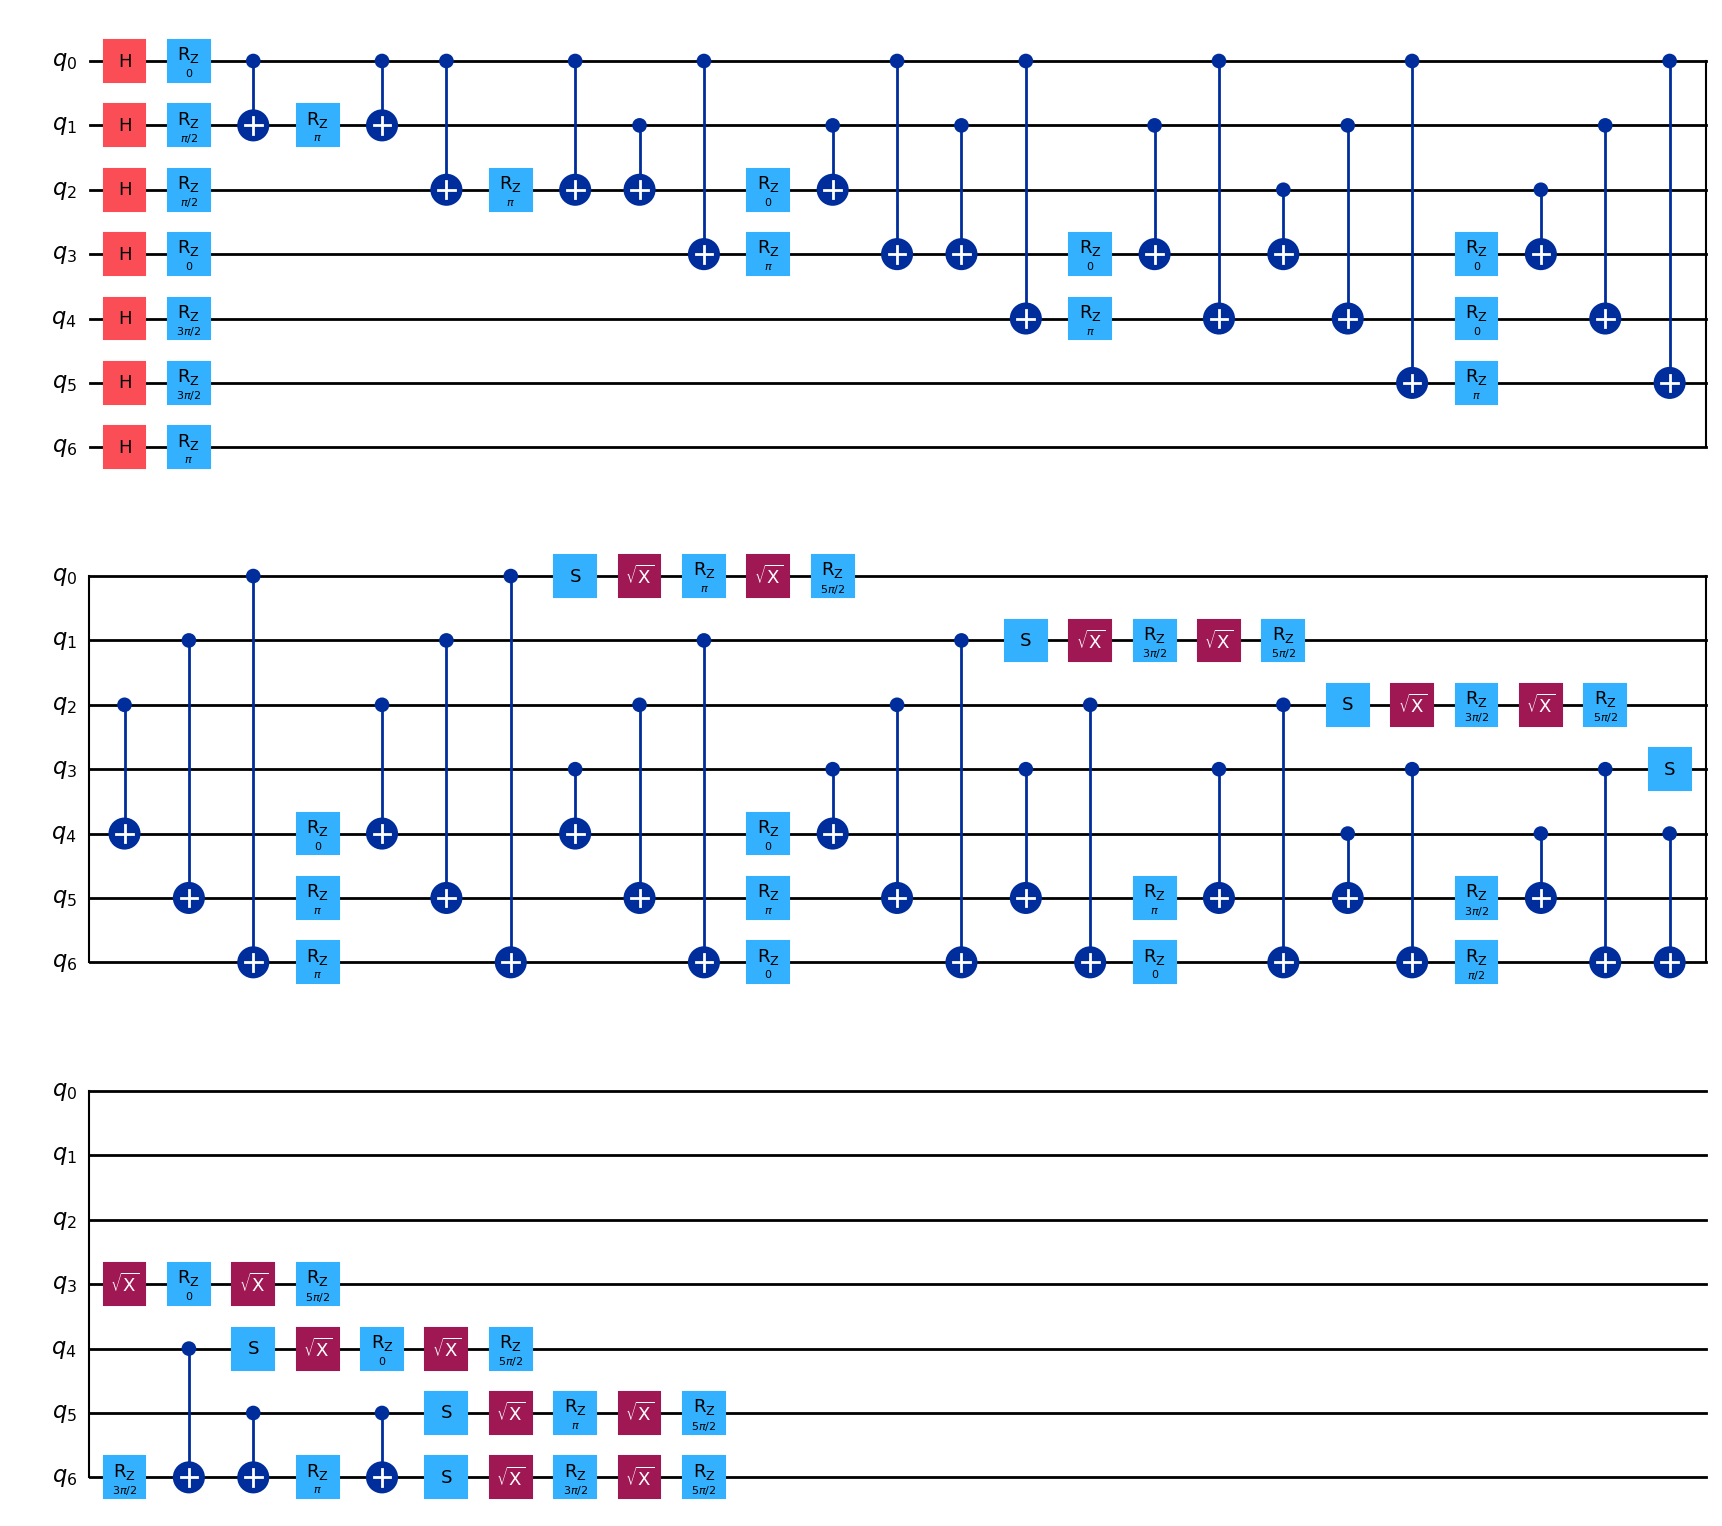

In [19]:
pcirc.assign_parameters(cafqa_angles).draw('mpl')

In [20]:
pcirc.parameters

ParameterView([Parameter(-130.0*gamma_1), Parameter(-132.0*gamma_15), Parameter(-195.0*gamma_3), Parameter(-260.0*gamma_6), Parameter(-65.0*gamma_0), Parameter(-66.0*gamma_10), Parameter(-66.0*gamma_21), Parameter(11.0*gamma_11), Parameter(11.0*gamma_22), Parameter(11.0*gamma_26), Parameter(132.0*gamma_9), Parameter(2.0*beta_0), Parameter(2.0*beta_1), Parameter(2.0*beta_2), Parameter(2.0*beta_3), Parameter(2.0*beta_4), Parameter(2.0*beta_5), Parameter(2.0*beta_6), Parameter(22.0*gamma_12), Parameter(22.0*gamma_16), Parameter(22.0*gamma_2), Parameter(22.0*gamma_20), Parameter(22.0*gamma_23), Parameter(22.0*gamma_27), Parameter(33.0*gamma_13), Parameter(33.0*gamma_24), Parameter(33.0*gamma_4), Parameter(44.0*gamma_14), Parameter(44.0*gamma_17), Parameter(44.0*gamma_25), Parameter(44.0*gamma_7), Parameter(66.0*gamma_18), Parameter(66.0*gamma_5), Parameter(88.0*gamma_19), Parameter(88.0*gamma_8)])

In [21]:
dag = circuit_to_dag(pcirc)
param_list = [(node.op.params)[0] for node in dag.op_nodes() if node.op.params and isinstance(node.op.params[0], ParameterExpression)]
param_list

[Parameter(-65.0*gamma_0),
 Parameter(-130.0*gamma_1),
 Parameter(22.0*gamma_2),
 Parameter(-195.0*gamma_3),
 Parameter(33.0*gamma_4),
 Parameter(66.0*gamma_5),
 Parameter(-260.0*gamma_6),
 Parameter(44.0*gamma_7),
 Parameter(88.0*gamma_8),
 Parameter(132.0*gamma_9),
 Parameter(-66.0*gamma_10),
 Parameter(11.0*gamma_11),
 Parameter(22.0*gamma_12),
 Parameter(33.0*gamma_13),
 Parameter(44.0*gamma_14),
 Parameter(-132.0*gamma_15),
 Parameter(22.0*gamma_16),
 Parameter(44.0*gamma_17),
 Parameter(66.0*gamma_18),
 Parameter(88.0*gamma_19),
 Parameter(22.0*gamma_20),
 Parameter(-66.0*gamma_21),
 Parameter(11.0*gamma_22),
 Parameter(2.0*beta_0),
 Parameter(22.0*gamma_23),
 Parameter(2.0*beta_1),
 Parameter(33.0*gamma_24),
 Parameter(2.0*beta_2),
 Parameter(44.0*gamma_25),
 Parameter(2.0*beta_3),
 Parameter(11.0*gamma_26),
 Parameter(2.0*beta_4),
 Parameter(22.0*gamma_27),
 Parameter(2.0*beta_5),
 Parameter(2.0*beta_6)]

In [ ]:
def test_energy_functions(circuit, cost_hamiltonian, reversed_paulis, coeffs, tolerance=5, num_runs=100):
    for _ in range(num_runs):
        # Generate random parameters
        random_params = [random.randint(0, 3) for _ in range(circuit.num_parameters)]

        # ordered_params = [param.name for param in pcirc.parameters]
        ordered_params = [param for param in trial_param_list]

        mults = [
            (np.pi / (2 * 1)) 
            for param in ordered_params
        ]
        cafqa_angles = [param * multiplier for param, multiplier in zip(random_params, mults)]

        # Calculate energy using cafqa_params_energy
        cafqa_energy = np.mean([cafqa_params_energy(circuit, cost_hamiltonian, cafqa_angles) for _ in range(10)])
        # Assign parameters to stim circuit
        stim_circ.assign(random_params)
        
        # Calculate energy using stim_exp_val
        stim_energy = stim_exp_val(stim_circ.stim_circuit(), reversed_paulis, coeffs)
        
        # Check if the energies are close within the given tolerance
        assert np.isclose(cafqa_energy, stim_energy, atol=tolerance), f"Energy mismatch: cafqa_energy={cafqa_energy}, stim_energy={stim_energy}"
        if np.isclose(cafqa_energy, stim_energy, atol=tolerance):
            print(f"Matching energies: cafqa_energy={cafqa_energy}, stim_energy={stim_energy}")

    print(f"All {num_runs} runs passed within tolerance {tolerance}")

# Usage
test_energy_functions(pcirc, cost_hamiltonian, reversed_paulis, coeffs)

Matching energies: cafqa_energy=31.976806640625, stim_energy=33.0
Matching energies: cafqa_energy=-0.4261474609375, stim_energy=0.0
Matching energies: cafqa_energy=1.76884765625, stim_energy=0.0
Matching energies: cafqa_energy=-0.19423828125, stim_energy=0.0
Matching energies: cafqa_energy=0.7655029296875, stim_energy=0.0
Matching energies: cafqa_energy=0.4739013671875, stim_energy=0.0
Matching energies: cafqa_energy=23.9842529296875, stim_energy=22.0
Matching energies: cafqa_energy=1.196142578125, stim_energy=0.0
Matching energies: cafqa_energy=-0.2645751953125, stim_energy=0.0
Matching energies: cafqa_energy=0.14326171875, stim_energy=0.0
All 10 runs passed within tolerance 5
